In [1]:
import tensorflow as tf
import numpy as np                                
import matplotlib.pyplot as plt
import keras as k
#from tensorflow.examples.tutorials.mnist import input_data
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from keras.optimizers import SGD, Adam
from keras.models import load_model
from keras import backend as K
tf.random.set_seed(42)

2025-01-12 17:47:00.927530: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Matplotlib created a temporary config/cache directory at /tmp/matplotlib-1ogx6285 because the default path (/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
from tensorflow.python.client import device_lib

def get_available_gpus():
    local_device_protos = device_lib.list_local_devices()
    return [x.name for x in local_device_protos if x.device_type == 'GPU']

get_available_gpus()

2025-01-12 17:47:03.445450: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /device:GPU:0 with 79090 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:85:00.0, compute capability: 8.0
2025-01-12 17:47:03.447190: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /device:GPU:1 with 79090 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:c7:00.0, compute capability: 8.0


['/device:GPU:0', '/device:GPU:1']

In [3]:
mnist_dir = "mnist/"
x_train = np.load(mnist_dir + "x_train.npy")
x_test = np.load(mnist_dir + "x_test.npy")
y_train = np.load(mnist_dir + "y_train.npy")
y_test = np.load(mnist_dir + "y_test.npy")

In [4]:
img_rows, img_cols = 28,28
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
input_shape = (img_rows, img_cols, 1)
x_test=x_test.astype('float32')
x_train=x_train.astype('float32')
mean=np.mean(x_train)
std=np.std(x_train)
x_test = (x_test-mean)/std
x_train = (x_train-mean)/std

In [5]:
#labels
num_classes=10
y_train = k.utils.to_categorical(y_train, num_classes)
y_test = k.utils.to_categorical(y_test, num_classes)

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the data augmentation generator with various transformations
datagen = ImageDataGenerator(
    rotation_range=20,         # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,     # Randomly shift images horizontally by 20%
    height_shift_range=0.2,    # Randomly shift images vertically by 20%
    shear_range=0.2,           # Shear images randomly by up to 20%
    zoom_range=0.2,            # Zoom into images by up to 20%
    horizontal_flip=True,      # Randomly flip images horizontally
    fill_mode='nearest'        # Fill in any empty pixels after transformations
)

augmented_images = []
augmented_labels = []

for i in range(len(x_train)):
    image = x_train[i]
    label = y_train[i]
    
    # Generate multiple augmentations of each image
    for _ in range(10):  # Create 10 augmented versions for each image 
        augmented_image = datagen.random_transform(image)
        augmented_images.append(augmented_image)
        augmented_labels.append(label)

# Convert the list to numpy arrays
augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

# Now, you have a larger dataset with augmented samples
print("Original dataset size:", x_train.shape[0])
print("Augmented dataset size:", augmented_images.shape[0])

# Combine original data with augmented data (optional)
x_train = np.concatenate((x_train, augmented_images), axis=0)
y_train = np.concatenate((y_train, augmented_labels), axis=0)

Original dataset size: 60000
Augmented dataset size: 600000


In [7]:
#build model
with tf.device("/GPU:0"):
    num_filter=32
    num_dense=512
    drop_dense=0.7
    ac='relu'
    learningrate=0.001
    
    model = Sequential()
    
    model.add(Conv2D(num_filter, (3, 3), activation=ac, input_shape=(28, 28, 1),padding='same'))
    model.add(BatchNormalization(axis=-1))
    model.add(Conv2D(num_filter, (3, 3), activation=ac,padding='same'))
    model.add(BatchNormalization(axis=-1))
    model.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 14x14x32
    
    model.add(Conv2D(2*num_filter, (3, 3), activation=ac,padding='same'))
    model.add(BatchNormalization(axis=-1))
    model.add(Conv2D(2*num_filter, (3, 3), activation=ac,padding='same'))
    model.add(BatchNormalization(axis=-1))
    model.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 7x7x64 = 3136 neurons
    
    model.add(Flatten())                        
    model.add(Dense(num_dense, activation=ac))
    model.add(BatchNormalization())
    model.add(Dropout(drop_dense))
    model.add(Dense(10, activation='softmax'))
    
    adm=Adam(lr=learningrate, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
    model.compile(loss='categorical_crossentropy', metrics=['accuracy'],optimizer=adm)

2025-01-12 17:49:01.449976: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79090 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:85:00.0, compute capability: 8.0
2025-01-12 17:49:01.451338: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79090 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:c7:00.0, compute capability: 8.0
/usr/local/lib/python3.8/dist-packages/keras/optimizers/legacy/adam.py:117: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [8]:
batch_sizes = [1024, 2048, 4096, 8192, 10000, 15000]
#batch_sizes = [8, 16, 32, 64, 128, 256, 512, 1024]

In [9]:
# with GPU (the default in my setup)
import time
times_gpu = []
with tf.device("/GPU:0"):
    for k in batch_sizes:
        print("Batch size: " + str(k)) 
        time_start = time.time_ns()
        model.fit(x_train, y_train, batch_size=k, epochs=1, validation_data=(x_test, y_test))
        time_end = time.time_ns()
        times_gpu.append(time_end-time_start)

Batch size: 1024


2025-01-12 17:49:07.209771: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2025-01-12 17:49:07.583337: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


645/645 [==============================] - 12s 15ms/step - loss: 0.3359 - accuracy: 0.8987 - val_loss: 0.0605 - val_accuracy: 0.9805
Batch size: 2048
323/323 [==============================] - 10s 27ms/step - loss: 0.1100 - accuracy: 0.9663 - val_loss: 0.0335 - val_accuracy: 0.9893
Batch size: 4096
162/162 [==============================] - 10s 50ms/step - loss: 0.0836 - accuracy: 0.9742 - val_loss: 0.0260 - val_accuracy: 0.9916
Batch size: 8192
81/81 [==============================] - 14s 125ms/step - loss: 0.0713 - accuracy: 0.9779 - val_loss: 0.0248 - val_accuracy: 0.9914
Batch size: 10000
66/66 [==============================] - 12s 118ms/step - loss: 0.0648 - accuracy: 0.9799 - val_loss: 0.0260 - val_accuracy: 0.9909
Batch size: 15000
44/44 [==============================] - 14s 193ms/step - loss: 0.0604 - accuracy: 0.9811 - val_loss: 0.0242 - val_accuracy: 0.9917


In [10]:
times_gpus = []
strategy = tf.distribute.MirroredStrategy(cross_device_ops=tf.distribute.ReductionToOneDevice())
with strategy.scope():
    num_filter=32
    num_dense=512
    drop_dense=0.7
    ac='relu'
    learningrate=0.001

    model2 = Sequential()

    model2.add(Conv2D(num_filter, (3, 3), activation=ac, input_shape=(28, 28, 1),padding='same'))
    model2.add(BatchNormalization(axis=-1))
    model2.add(Conv2D(num_filter, (3, 3), activation=ac,padding='same'))
    model2.add(BatchNormalization(axis=-1))
    model2.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 14x14x32

    model2.add(Conv2D(2*num_filter, (3, 3), activation=ac,padding='same'))
    model2.add(BatchNormalization(axis=-1))
    model2.add(Conv2D(2*num_filter, (3, 3), activation=ac,padding='same'))
    model2.add(BatchNormalization(axis=-1))
    model2.add(MaxPooling2D(pool_size=(2, 2)))   # reduces to 7x7x64 = 3136 neurons

    model2.add(Flatten())                        
    model2.add(Dense(num_dense, activation=ac))
    model2.add(BatchNormalization())
    model2.add(Dropout(drop_dense))
    model2.add(Dense(10, activation='softmax'))

    adm=Adam(lr=learningrate, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
    model2.compile(loss='categorical_crossentropy', metrics=['accuracy'],optimizer=adm)

    for k in [ 2*k for k in batch_sizes]:
        print("Batch size: " + str(k)) 
        time_start = time.time_ns()
        model2.fit(x_train, y_train, batch_size=k, epochs=1, validation_data=(x_test, y_test))
        time_end = time.time_ns()
        times_gpus.append(time_end-time_start)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensor

2025-01-12 17:50:39.923148: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype float and shape [660000,10]
	 [[{{node Placeholder/_11}}]]
2025-01-12 17:50:39.923483: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype float and shape [660000,10]
	 [[{{node Placeholder/_11}}]]


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1').
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1').
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1').
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1').
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1').
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:

2025-01-12 17:50:42.755540: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600


323/323 [==============================] - ETA: 0s - loss: 0.4231 - accuracy: 0.8737

...

2025-01-12 17:51:42.311735: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype float and shape [10000,10]
	 [[{{node Placeholder/_11}}]]
2025-01-12 17:51:42.312076: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype float and shape [10000,10]
	 [[{{node Placeholder/_11}}]]


33/33 [==============================] - 9s 154ms/step - loss: 0.0815 - accuracy: 0.9747 - val_loss: 0.0391 - val_accuracy: 0.9870
Batch size: 30000


2025-01-12 17:51:47.642962: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype float and shape [660000,10]
	 [[{{node Placeholder/_11}}]]
2025-01-12 17:51:47.643353: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [660000,28,28,1]
	 [[{{node Placeholder/_10}}]]


22/22 [==============================] - 11s 222ms/step - loss: 0.0771 - accuracy: 0.9760 - val_loss: 0.0318 - val_accuracy: 0.9899


2025-01-12 17:51:58.675577: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [10000,28,28,1]
	 [[{{node Placeholder/_10}}]]
2025-01-12 17:51:58.675910: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype float and shape [10000,10]
	 [[{{node Placeholder/_11}}]]


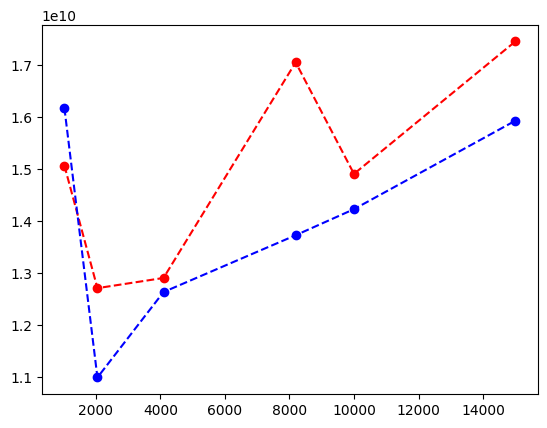

In [11]:
import matplotlib.pyplot as plt
plt.plot(batch_sizes,times_gpu,'ro')
plt.plot(batch_sizes,times_gpu,'r--')
plt.plot(batch_sizes,times_gpus,'bo')
plt.plot(batch_sizes,times_gpus,'b--')
